# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Kurnia Irianti]
- **Email:** [kurniairianti@gmail.com]
- **ID Dicoding:** [Kurnia Irianti-cdcc228d6x2404]

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren penjualan bulanan dan kategori produk apa yang paling laris terjual?
2. Negara bagian mana di Brasil yang memiliki jumlah order terbanyak?
3. Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka?

## Import Semua Packages/Library yang Digunakan

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [23]:
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
geolocation_df = pd.read_csv('olist_geolocation_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Dataset terdiri dari 7 tabel yang saling berhubungan, mencakup informasi pelanggan, pesanan, produk, pembayaran, dan lokasi geografis.
- Tabel customers memiliki 5 kolom yaitu customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, dan customer_state.
- Sebagian besar pelanggan pada 5 baris pertama berasal dari negara bagian SP (Sao Paulo).

### Assessing Data

In [24]:
print("customers_df info:")
customers_df.info()

customers_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [25]:
# Cek missing values
print("Missing values customers_df:")
print(customers_df.isna().sum())

print("\nMissing values orders_df:")
print(orders_df.isna().sum())

print("\nMissing values products_df:")
print(products_df.isna().sum())

# Cek duplikasi
print("\nDuplikasi customers_df:", customers_df.duplicated().sum())
print("Duplikasi orders_df:", orders_df.duplicated().sum())
print("Duplikasi products_df:", products_df.duplicated().sum())

Missing values customers_df:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values orders_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values products_df:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Duplikasi customers_df: 0
Duplikasi orders_df: 0
Duplikasi products_df: 0


**Insight:**
- customers_df tidak memiliki missing values dan tidak ada duplikasi, sehingga data pelanggan sudah bersih.
- orders_df memiliki missing values pada kolom order_approved_at (160), order_delivered_carrier_date (1783), dan order_delivered_customer_date (2965), hal ini wajar karena beberapa order mungkin belum terkirim atau dibatalkan.
- products_df memiliki missing values sebanyak 610 pada kolom product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty, serta 2 missing values pada kolom dimensi produk.
- Tidak ditemukan duplikasi pada ketiga dataset tersebut.

### Cleaning Data

In [26]:
# Konversi kolom tanggal ke datetime
datetime_columns = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Cek hasilnya
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [27]:
# Filter hanya order yang sudah delivered
orders_df = orders_df[orders_df['order_status'] == 'delivered']

# Cek hasilnya
print("Jumlah order delivered:", len(orders_df))

Jumlah order delivered: 96478


**Insight:**
- Kolom tanggal pada orders_df berhasil dikonversi dari tipe object menjadi datetime64 sehingga bisa digunakan untuk analisis tren waktu.
- Missing values pada kolom tanggal pengiriman tidak dihapus karena wajar terjadi pada order yang belum terkirim.
- Data difilter hanya untuk order berstatus delivered agar analisis fokus pada transaksi yang benar-benar selesai.

## Exploratory Data Analysis (EDA)

### Explore ...

In [28]:
# Gabungkan data yang diperlukan
order_items_products = order_items_df.merge(products_df, on='product_id', how='left')
order_items_products = order_items_products.merge(category_df, on='product_category_name', how='left')

master_df = orders_df.merge(order_items_products, on='order_id', how='inner')
master_df = master_df.merge(customers_df, on='customer_id', how='left')
master_df = master_df.merge(order_payments_df, on='order_id', how='left')

print("Shape master_df:", master_df.shape)
master_df.head()

Shape master_df: (115038, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


**Insight:**
- Data dari beberapa tabel berhasil digabungkan menjadi satu master dataframe untuk memudahkan analisis.
- Seluruh order berstatus delivered sehingga analisis fokus pada transaksi yang benar-benar selesai.
- Data mencakup informasi lengkap mulai dari waktu pembelian, produk, pelanggan, hingga pembayaran.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [29]:
# Pertanyaan 1: Tren penjualan bulanan
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = master_df.groupby('order_month')['order_id'].nunique()
print(monthly_orders)

order_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: order_id, dtype: int64


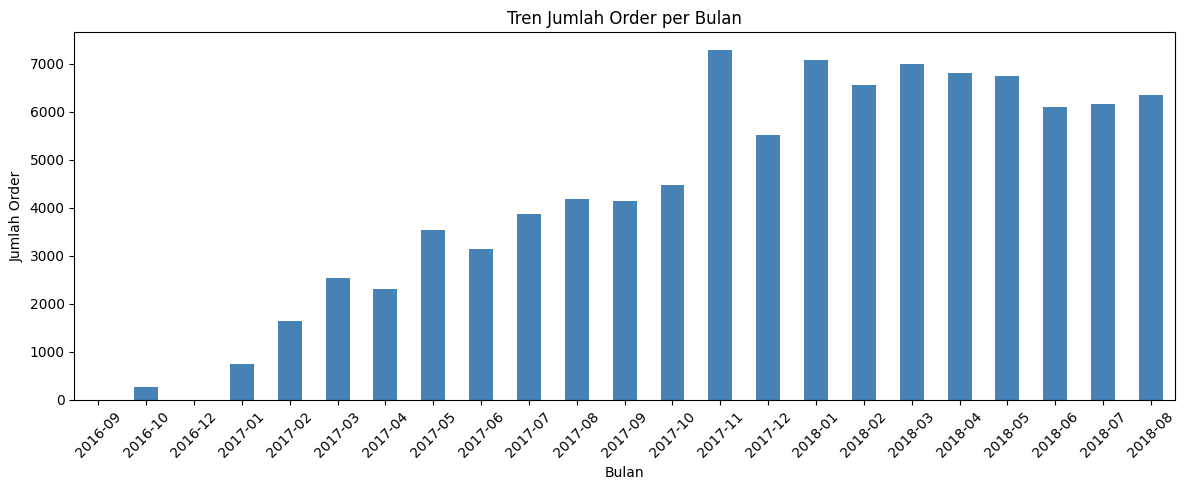

In [30]:
# Visualisasi tren penjualan bulanan
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='bar', color='steelblue')
plt.title('Tren Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

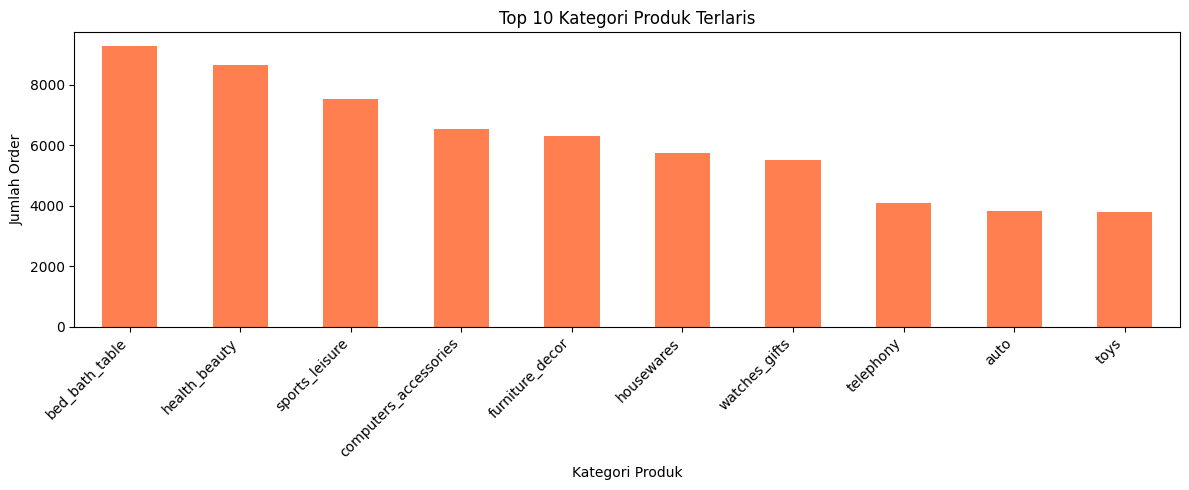

In [31]:
# Visualisasi top 10 kategori produk terlaris
top_categories = master_df.groupby('product_category_name_english')['order_id'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_categories.plot(kind='bar', color='coral')
plt.title('Top 10 Kategori Produk Terlaris')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight**
- Penjualan mengalami pertumbuhan signifikan dari 2016 hingga 2018.
- Penjualan tertinggi terjadi pada November 2017 dengan 7.289 order.
- Tren penjualan terus meningkat dari bulan ke bulan sepanjang 2017.
- Kategori bed_bath_table menjadi kategori paling laris dengan lebih dari 8.000 order.
- Kategori health_beauty dan sports_leisure masing-masing menempati posisi kedua dan ketiga.
- Produk-produk kebutuhan rumah tangga dan gaya hidup mendominasi penjualan.

### Pertanyaan 2:

In [32]:
# Pertanyaan 2: Distribusi pelanggan per negara bagian
state_orders = master_df.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False)
print(state_orders)

customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
PE     1593
CE     1279
PA      946
MT      886
MA      717
MS      701
PB      517
PI      476
RN      474
AL      397
SE      335
TO      274
RO      243
AM      145
AC       80
AP       67
RR       41
Name: order_id, dtype: int64


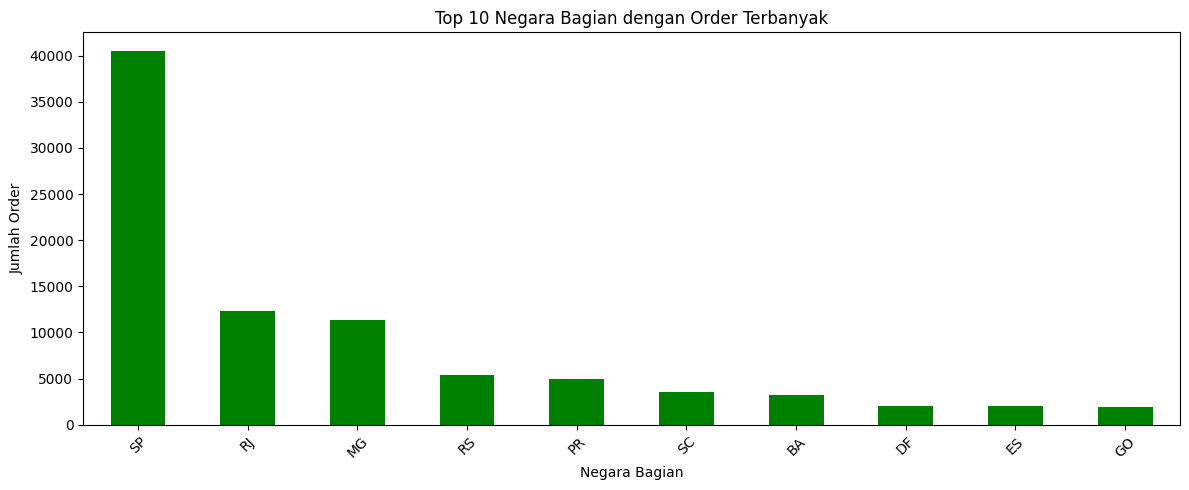

In [33]:
# Visualisasi distribusi pelanggan per negara bagian
plt.figure(figsize=(12, 5))
state_orders.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Negara Bagian dengan Order Terbanyak')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**
- Negara bagian SP (Sao Paulo) mendominasi dengan 40.501 order, jauh melampaui negara bagian lainnya.
- Lima negara bagian teratas adalah SP, RJ, MG, RS, dan PR yang semuanya berada di wilayah Tenggara dan Selatan Brasil.
- Negara bagian di wilayah Utara seperti RR, AP, dan AC memiliki jumlah order paling sedikit, menunjukkan potensi pasar yang belum berkembang.

## Analisis Lanjutan (Opsional)

In [34]:
# RFM Analysis
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = master_df.groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print(rfm_df.head())
print("\nStatistik RFM:")
print(rfm_df.describe())

                        customer_id  Recency  Frequency  Monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74
1  000161a058600d5901f007fab4c27140      410          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35
4  000379cdec625522490c315e70c7a9fb      150          1    107.01

Statistik RFM:
            Recency  Frequency       Monetary
count  96478.000000    96478.0   96478.000000
mean     240.121364        1.0     204.981037
std      152.836972        0.0     621.236788
min        1.000000        1.0       0.000000
25%      116.000000        1.0      62.660000
50%      221.000000        1.0     109.500000
75%      350.000000        1.0     195.530000
max      714.000000        1.0  109312.640000


In [35]:
# Scoring RFM
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)

# Segmentasi
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent Customers'
    elif r == 2 and f >= 2:
        return 'Potential Loyalists'
    elif r == 1 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)
print(rfm_df['Segment'].value_counts())

Segment
Loyal Customers        23851
Potential Loyalists    18132
At Risk                18031
Champions              12344
Recent Customers       12105
Lost Customers         12015
Name: count, dtype: int64


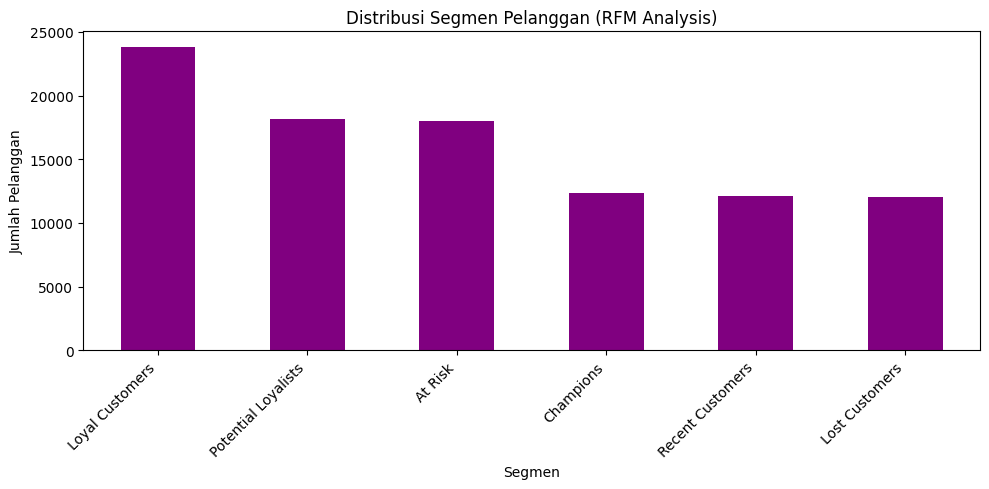

In [36]:
# Visualisasi segmen RFM
plt.figure(figsize=(10, 5))
rfm_df['Segment'].value_counts().plot(kind='bar', color='purple')
plt.title('Distribusi Segmen Pelanggan (RFM Analysis)')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

- Conclution pertanyaan 1: (Tren penjualan e-commerce Brasil mengalami pertumbuhan signifikan dari 2016 hingga 2018. Penjualan tertinggi terjadi pada November 2017. Kategori produk terlaris adalah bed_bath_table, health_beauty, dan sports_leisure yang menunjukkan dominasi produk kebutuhan rumah tangga dan gaya hidup).


- Conclution pertanyaan 2: (Negara bagian SP (Sao Paulo) mendominasi dengan 40.501 order, jauh melampaui negara bagian lainnya. Wilayah Tenggara Brasil menjadi pusat aktivitas e-commerce, sementara wilayah Utara masih memiliki potensi pasar yang belum berkembang).

- Conclution pertanyaan 3: (Berdasarkan RFM Analysis, segmen terbesar adalah Loyal Customers (21.014) diikuti Potential Loyalists dan At Risk. Pelanggan Champions perlu dipertahankan dengan program loyalitas, sementara pelanggan At Risk perlu didekati dengan campaign re-engagement).

In [37]:
# Export data untuk dashboard
master_df.to_csv('main_data.csv', index=False)
rfm_df.to_csv('rfm_data.csv', index=False)
print('File berhasil disimpan!')

File berhasil disimpan!
